In [1]:
import os
import sys
import tempfile
import pandas as pd
import numpy as np
import json 
import torch

import matplotlib.pyplot as plt

from datetime import datetime

from numpy.random import default_rng

# import packages from the project with sys
sys.path.append("/workspace/meteolibre_model")

In [3]:
example.keys()

dict_keys(['hour', 'minute', 'time_radar', 'datetime', 'id', 'satellite', 'radar', 'groundstation', 'ground_height', 'landcover'])

In [31]:
import numpy as np
from datasets import load_dataset

# The command is exactly the same!
# The library handles the sharded files behind the scenes.
ds = load_dataset("meteolibre-dev/mtg_meteofrance_256", streaming=True)

i = 0

# You can iterate over it as if it were a single file
for example in ds["train"]:
    i += 1
    # Get the byte string
    satellite_bytes = example['satellite']
    # Convert bytes back to a NumPy array
    # You need to specify the correct dtype and shape
    satellite_array = np.frombuffer(satellite_bytes, dtype=np.int16).reshape(9, 4, 256, 256)

    hour = example['hour']
    minute = example['minute']
    datetime = example['datetime']
    radar =  np.frombuffer(example['radar'], dtype=np.float32).reshape(9, 256, 256)
    groundstation =  np.frombuffer(example['groundstation'], dtype=np.float32).reshape(9, 256, 256, 7)
    ground_height =  np.frombuffer(example['ground_height'], dtype=np.float32).reshape(256, 256)
    landcover =  np.frombuffer(example['landcover'], dtype=np.float32).reshape(256, 256, 4)

    # Now you can work with the array
    print(example['id'], satellite_array.shape)
    # 8977819051 (9, 4, 256, 256)
    if i > 2:
        break




Resolving data files:   0%|          | 0/1821 [00:00<?, ?it/s]

6566423421 (9, 4, 256, 256)
596130676 (9, 4, 256, 256)
7362800176 (9, 4, 256, 256)


In [33]:
datetime

'2025-04-19 12:00:00'

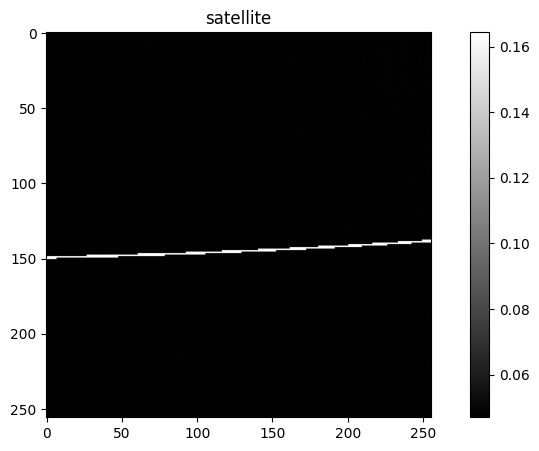

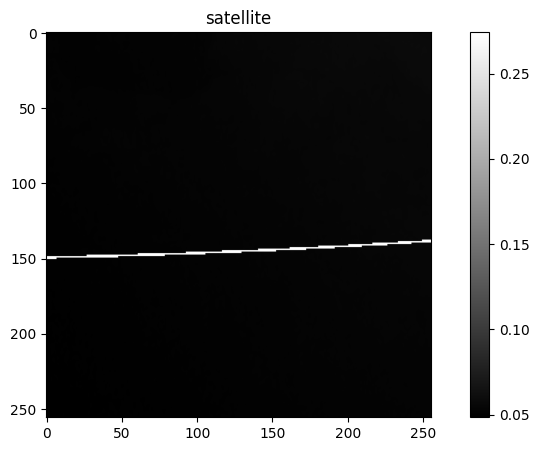

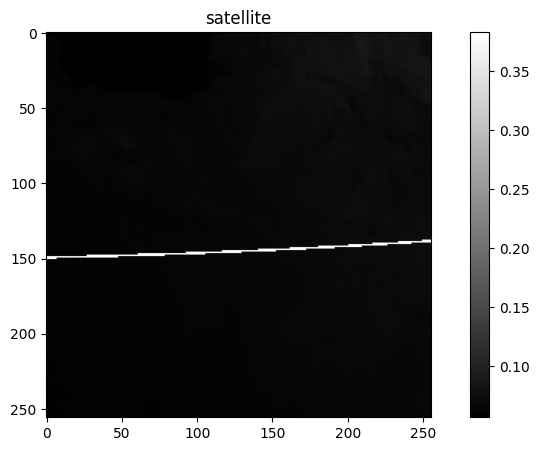

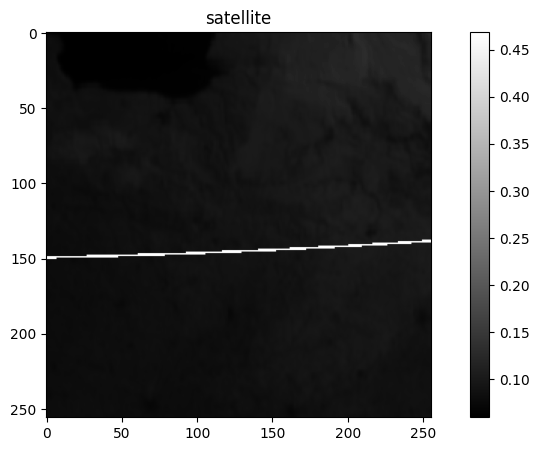

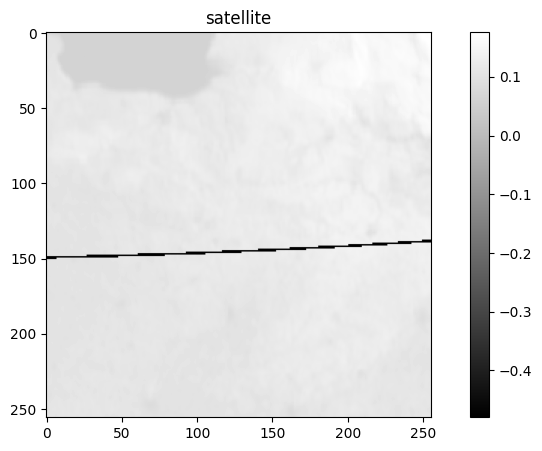

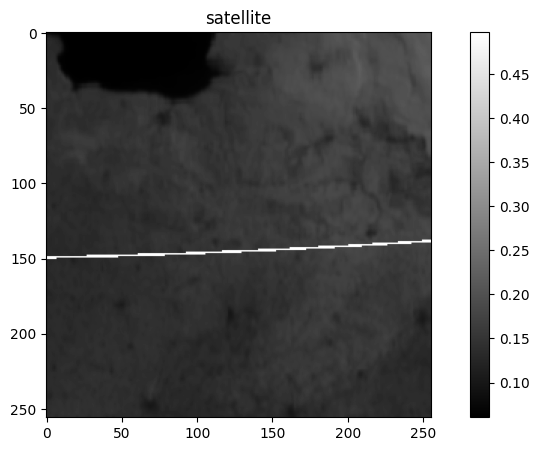

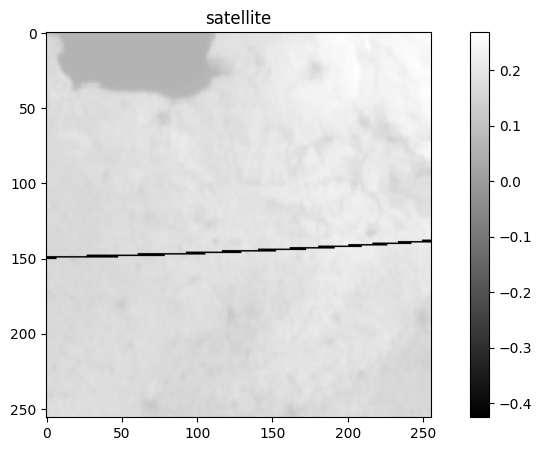

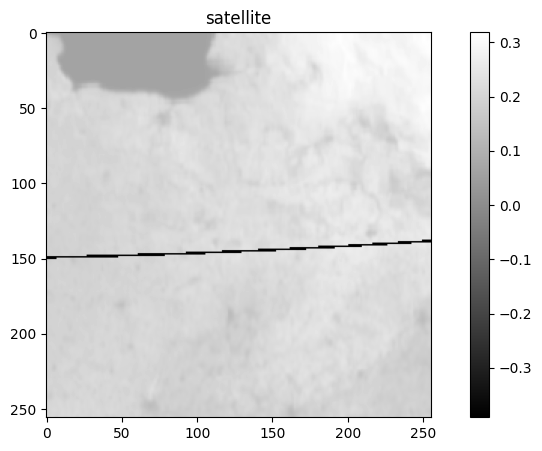

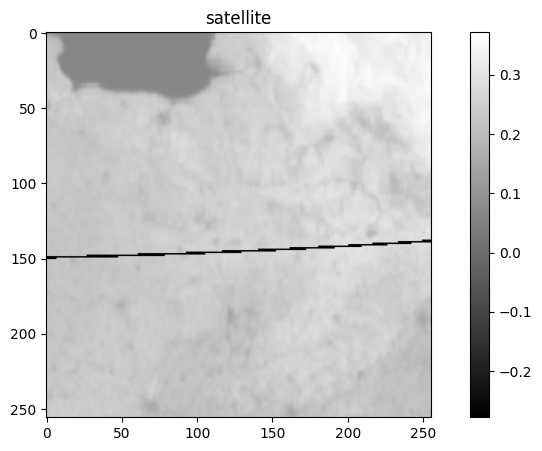

In [32]:
sattelite = satellite_array / 65536

for i in range(sattelite.shape[0]):
    # we plot the sattelite and the sattelite
    plt.figure(figsize=(10, 5))
    plt.imshow(sattelite[i, -3, :, :], cmap='gray')
    plt.title('satellite')
    plt.colorbar()


In [11]:
groundstation.shape

(9, 256, 256, 7)

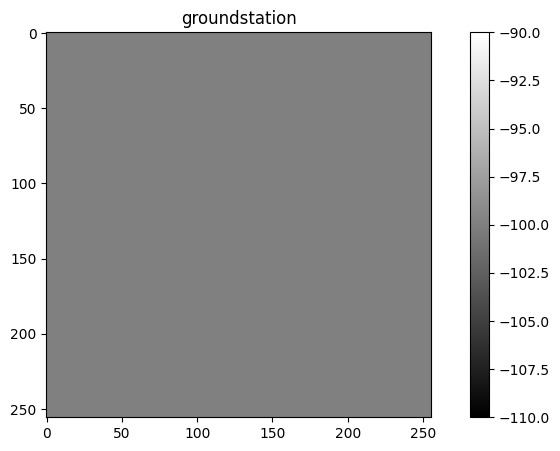

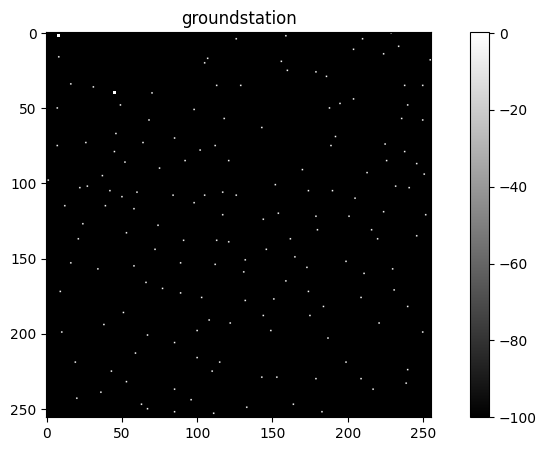

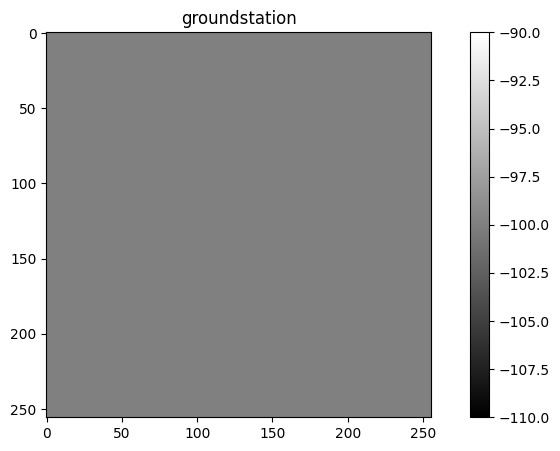

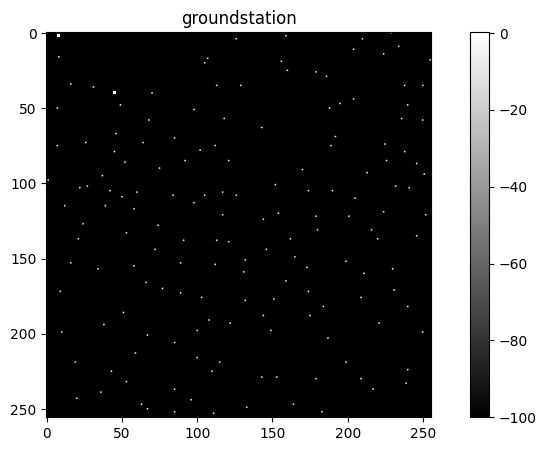

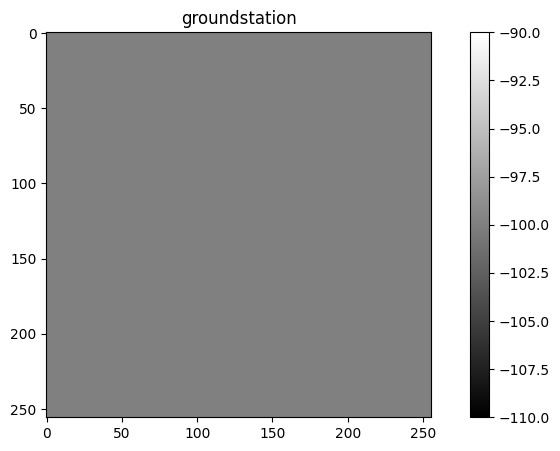

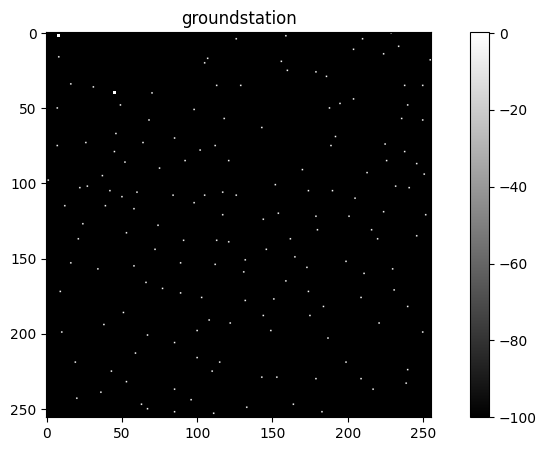

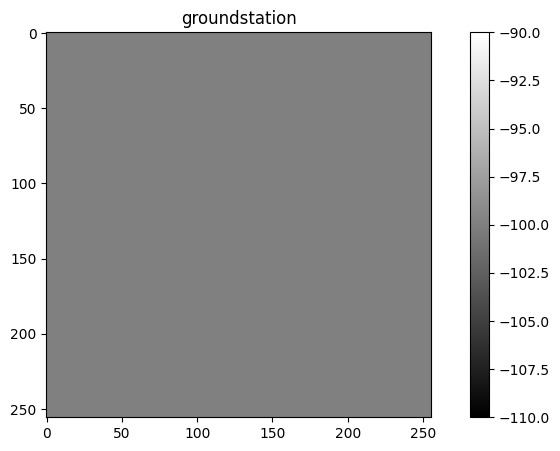

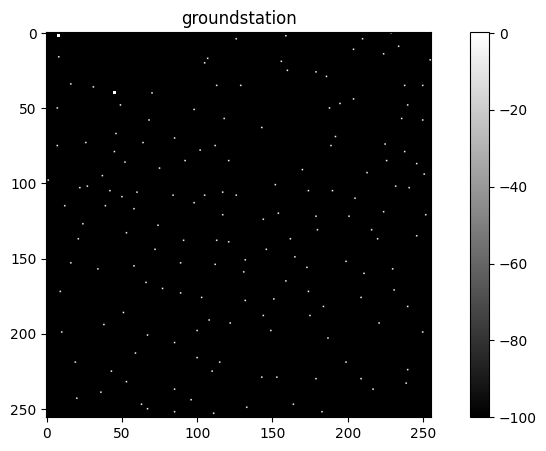

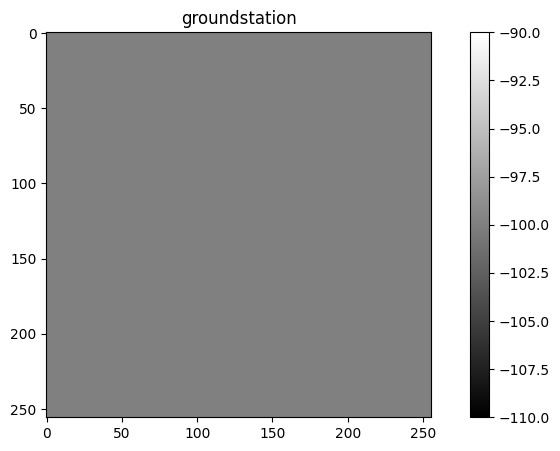

In [34]:

for i in range(groundstation.shape[0]):
    # we plot the groundstation and the groundstation
    plt.figure(figsize=(10, 5))
    plt.imshow(groundstation[i, :, :, 0], cmap='gray')
    plt.title('groundstation')
    plt.colorbar()

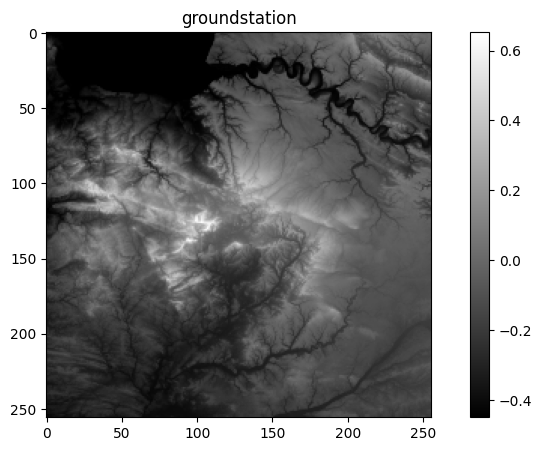

In [35]:

# we plot the groundstation and the groundstation
plt.figure(figsize=(10, 5))
plt.imshow(ground_height, cmap='gray')
plt.title('groundstation')
plt.colorbar()

In [18]:
landcover.shape

(256, 256, 4)

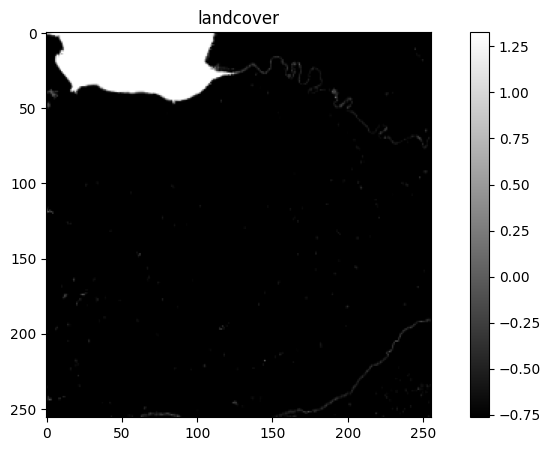

In [36]:

# we plot the groundstation and the groundstation
plt.figure(figsize=(10, 5))
plt.imshow(landcover[:, :, 3], cmap='gray')
plt.title('landcover')
plt.colorbar()